In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt

def f_samp_to_clk():
    n_bits = [8, 12, 14, 16, 18, 20, 24, 32]
    f_samp = [44.1, 48, 88.2, 96, 176.4, 192, 200, 216, 220, 225, 250, 333, 384]
    f_clk = []
    print("Possibilities \t\t\t F(sampling kHz) \t\t\t F(clock MHz)")
    for j in range(len(n_bits)):
        for i in range(len(f_samp)):
            f_clk = f_samp[i]*2**(n_bits[j])*1000
            print("{} \t\t\t\t {} \t\t\t\t\t {}".format(2**(n_bits[j]), f_samp[i], f_clk/1000000))

def sine_to_binary():
    amp = np.sin(np.array(range(0,360,5)) * np.pi / 180. )
    amp = amp+1
    amp = amp*(2**(7)-1)
    amp = amp.astype(int)
    amp_bin = amp[0:63+1]
    plt.plot(amp_bin)
    plt.show()
    print("Minimum value is: {}".format(min(amp_bin)))
    print("Maximum value is: {}".format(max(amp_bin)))
    print(amp_bin)
    for i in range(len(amp_bin)):
        print("{} : pwm_dc <= 'b{};".format(i, np.binary_repr(amp_bin[i], width=8)))

#f_samp_to_clk()
#sine_to_binary()

In [42]:
import serial
ser = serial.Serial('COM10', 115200, parity=serial.PARITY_NONE)

data_in = ser.read(1000000)
data_in = list(data_in)


ser.close()

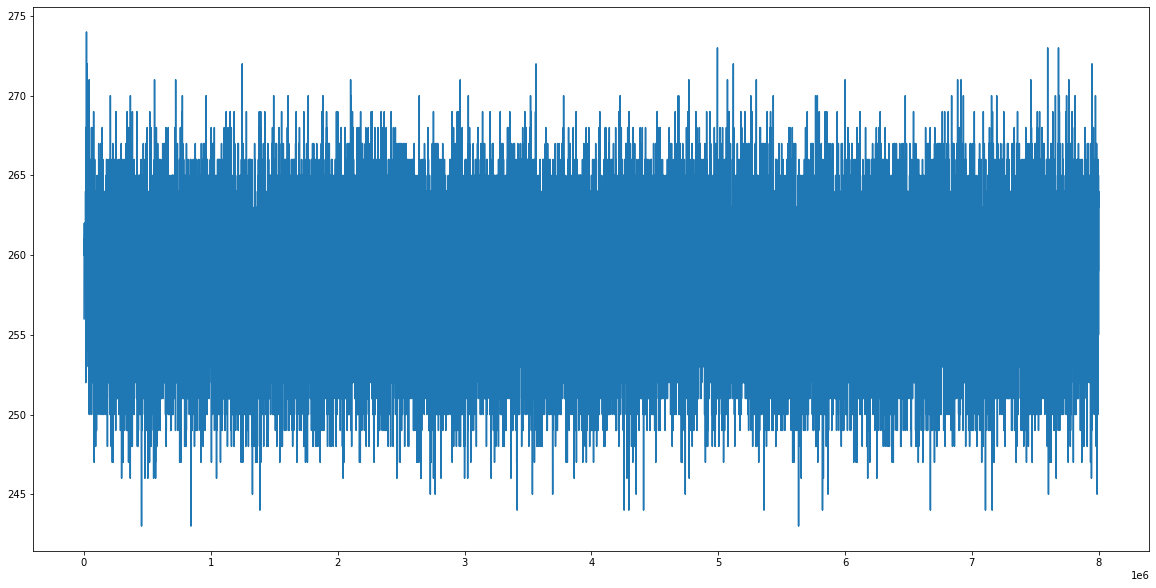

In [56]:
import matplotlib.pyplot as figure
import numpy as np

index = []
data_binary = []
for i in range(len(data_in)):
    data_binary.append(format(data_in[i], '08b'))
    #print(data_binary[i])
    
s = ''.join([str(i) for i in data_binary])

window = 500
total = len(s)/window

s_sum = 0
sound = []
#print(s)
for i in range(0, len(s)-window, 42):
    index.append(i)
    for j in range(window):
        s_sum = s_sum + int(s[j+i])
    sound.append(s_sum)
    s_sum = 0
    
    
xpoints = np.array(index)
ypoints = np.array(sound)
figure.rcParams["figure.figsize"] = (20, 10)
figure.plot(xpoints, ypoints)
figure.show()

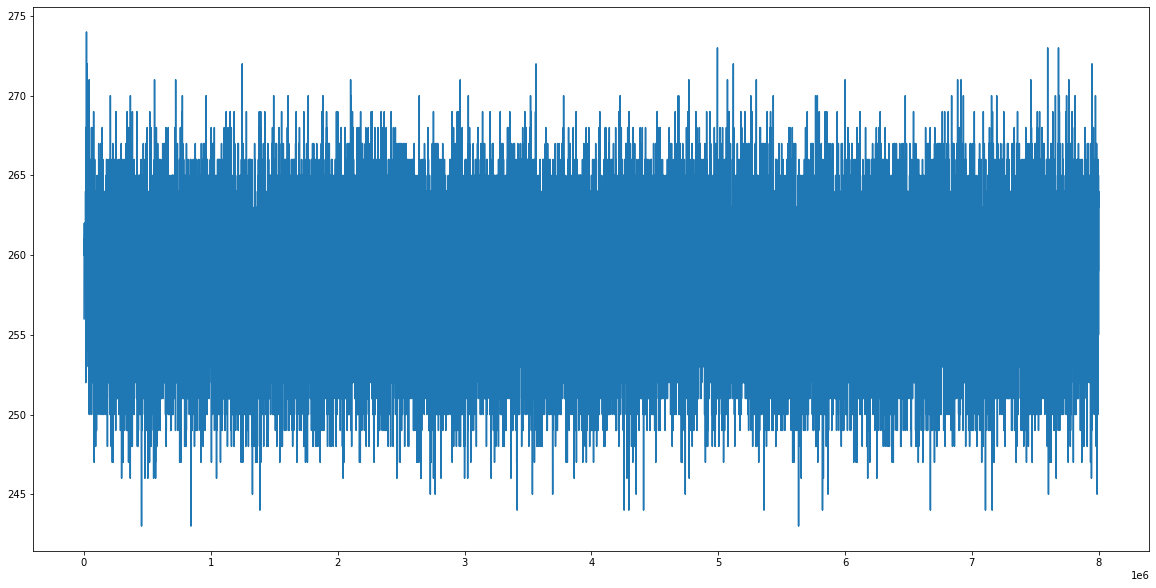

In [57]:
xpoints = np.array(index)
ypoints = np.array(sound)
figure.rcParams["figure.figsize"] = (20, 10)
figure.plot(xpoints, ypoints)
figure.show()

In [58]:
from scipy.io.wavfile import write

maxi = max(sound)
for i in range(len(sound)):
    sound[i] = sound[i]/maxi
    
data = sound
scaled = np.int16(data/np.max(np.abs(data)) * 32767)
write('test.wav', 48000, scaled)